In [1]:
! pip install --upgrade -q pandas numpy scikit-learn imbalanced-learn catboost matplotlib

In [2]:
from collections import Counter

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

from catboost import CatBoostClassifier

from utils.constants import *

In [3]:
df = pd.read_csv("../data/3_gold/dataset-processed-gb.csv")
X = df.drop("class", axis=1)
y = df["class"]
y = y.map(TARGET_LABEL_MAP)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=y
)

X_coarse = X_train.copy()
y_coarse = y_train.copy()
y_coarse = y_coarse.map(COARSE_LABEL_MAP)

high_risk_mask = y_train.isin([1, 2])
X_fine = X_train[high_risk_mask].copy()
y_fine = y_train[high_risk_mask].copy()
y_fine = y_fine.map(FINE_LABEL_MAP)

class_counts_coarse = Counter(y_coarse)
class_counts_fine = Counter(y_fine)

print("=== Coarse Data ===")
for class_idx, count in class_counts_coarse.items():
    print(f"Number of '{TARGET_NAMES_COARSE[class_idx]}' examples: {count}")

print("\n=== Fine Data ===")
for class_idx, count in class_counts_fine.items():
    print(f"Number of '{TARGET_NAMES_FINE[class_idx]}' examples: {count}")

=== Coarse Data ===
Number of 'high_risk' examples: 252418
Number of 'low_risk' examples: 359335

=== Fine Data ===
Number of 'alarm' examples: 228124
Number of 'severe' examples: 24294


In [ ]:
params_cat_coarse = {
    'iterations': 2000,
    'learning_rate': 0.05,
    'depth': 6,
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'auto_class_weights': 'Balanced',
    'early_stopping_rounds': 10,
    'random_state': RANDOM_STATE,
    'cat_features': list(CATEGORICAL_COLUMNS)
}
params_cat_fine = {
    'iterations': 2000,
    'learning_rate': 0.03,
    'depth': 8,
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',         
    'auto_class_weights': 'Balanced',
    'early_stopping_rounds': 10,
    'random_state': RANDOM_STATE,
    'cat_features': list(CATEGORICAL_COLUMNS)
}

def get_catboost_models():
    model_coarse = CatBoostClassifier(**params_cat_coarse)
    model_fine = CatBoostClassifier(**params_cat_fine)
    return model_coarse, model_fine


def eval_hierarchical(
    model_coarse, model_fine, X, y, 
    threshold_coarse=0.35, threshold_fine=0.5
):
    # Predict Coarse (0 = Low, 1 = High)
    probs_coarse = model_coarse.predict_proba(X)[:, 1]
    
    preds_coarse = (probs_coarse >= threshold_coarse).astype(int)
    final_preds = preds_coarse.copy()
    
    high_risk_indices = np.where(preds_coarse == 1)[0]
    
    if len(high_risk_indices) > 0:
        X_high_risk = X.iloc[high_risk_indices]
        
        # Predict Fine (0 = Alarm, 1 = Severe)
        probs_fine_local = model_fine.predict_proba(X_high_risk)[:, 1]
        preds_fine_local = (probs_fine_local >= threshold_fine).astype(int)
        
        # Map Fine predictions back to Global labels
        preds_fine_global = np.array([FINE_LABEL_MAP_REVERSE[p] for p in preds_fine_local])
        final_preds[high_risk_indices] = preds_fine_global

    print(classification_report(y, final_preds, target_names=["Low Risk", "Alarm", "Severe"]))
    return f1_score(y, final_preds, average='macro'), final_preds


def predict_soft_cascade(model_coarse, model_fine, X, y):
    # Get Probabilities from Coarse
    probs_coarse = model_coarse.predict_proba(X)
    p_high_risk = (probs_coarse[:, 1] * 1.1 + 0.1).clip(0.0, 1.0)
    
    # Get Probabilities from Fine
    probs_fine = model_fine.predict_proba(X) 
    p_severe_given_high = probs_fine[:, 1] # P(Severe | High)
        
    # P(Severe) = P(High) * P(Severe | High)
    p_severe_global = p_high_risk * p_severe_given_high
    
    # P(Alarm) = P(High) * (1 - P(Severe | High))
    p_alarm_global = p_high_risk * (1 - p_severe_given_high)
    
    # P(Low) = 1 - P(High)
    p_low_global = 1.0 - p_high_risk
    
    final_probs = np.vstack([p_low_global, p_alarm_global, p_severe_global]).T

    weights = np.array([0.9, 1.1, 1.15])
    weighted_probs = final_probs * weights
    final_preds = np.argmax(weighted_probs, axis=1)

    print(classification_report(y, final_preds, target_names=["Low Risk", "Alarm", "Severe"]))
    return f1_score(y, final_preds, average='macro'), final_preds


def train_hierarchical_catboost(X_coarse, y_coarse, X_fine, y_fine):
    X_train_coarse, X_val_coarse, y_train_coarse, y_val_coarse = train_test_split(
        X_coarse, y_coarse, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=y_coarse
    )
    X_train_fine, X_val_fine, y_train_fine, y_val_fine = train_test_split(
        X_fine, y_fine, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=y_fine
    )
    
    model_coarse, model_fine = get_catboost_models()
    
    print("Training Coarse Model...")
    model_coarse.fit(
        X_train_coarse, y_train_coarse,
        eval_set=(X_val_coarse, y_val_coarse),
        use_best_model=True
    )

    print("Training Fine Model...")
    model_fine.fit(
        X_train_fine, y_train_fine,
        eval_set=(X_val_fine, y_val_fine) if len(X_val_fine) > 0 else None,
        use_best_model=True if len(X_val_fine) > 0 else False
    )
    return model_coarse, model_fine

In [92]:
model_coarse, model_fine = train_hierarchical_catboost(X_coarse, y_coarse, X_fine, y_fine)

Training Coarse Model...
0:	test: 0.7367730	best: 0.7367730 (0)	total: 163ms	remaining: 5m 25s
1:	test: 0.7523886	best: 0.7523886 (1)	total: 306ms	remaining: 5m 5s
2:	test: 0.7524166	best: 0.7524166 (2)	total: 471ms	remaining: 5m 13s
3:	test: 0.7524720	best: 0.7524720 (3)	total: 617ms	remaining: 5m 8s
4:	test: 0.7525354	best: 0.7525354 (4)	total: 723ms	remaining: 4m 48s
5:	test: 0.7550286	best: 0.7550286 (5)	total: 872ms	remaining: 4m 49s
6:	test: 0.7560109	best: 0.7560109 (6)	total: 1.02s	remaining: 4m 50s
7:	test: 0.7560817	best: 0.7560817 (7)	total: 1.15s	remaining: 4m 45s
8:	test: 0.7570720	best: 0.7570720 (8)	total: 1.3s	remaining: 4m 48s
9:	test: 0.7602945	best: 0.7602945 (9)	total: 1.44s	remaining: 4m 47s
10:	test: 0.7636790	best: 0.7636790 (10)	total: 1.6s	remaining: 4m 48s
11:	test: 0.7645976	best: 0.7645976 (11)	total: 1.74s	remaining: 4m 48s
12:	test: 0.7653099	best: 0.7653099 (12)	total: 1.88s	remaining: 4m 47s
13:	test: 0.7665101	best: 0.7665101 (13)	total: 2.03s	remaining

              precision    recall  f1-score   support

    Low Risk       0.83      0.64      0.72     63413
       Alarm       0.55      0.56      0.55     40257
      Severe       0.14      0.58      0.22      4287

    accuracy                           0.61    107957
   macro avg       0.51      0.59      0.50    107957
weighted avg       0.70      0.61      0.64    107957



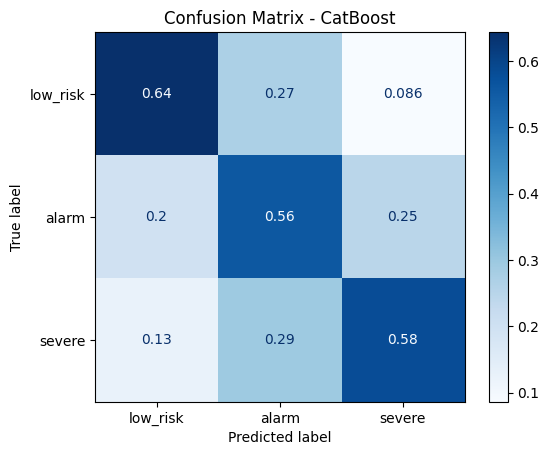

In [95]:
# Plot confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

f1, preds = predict_soft_cascade(
    model_coarse, model_fine, X_test, y_test
)

ConfusionMatrixDisplay.from_predictions(
    y_test, preds, display_labels=TARGET_NAMES, cmap=plt.cm.Blues, normalize='true'
)
plt.title("Confusion Matrix - CatBoost")
plt.show()